In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2
import faiss
import torch
from pathlib import Path
from facenet_pytorch import MTCNN, InceptionResnetV1
import yaml
import json
import os

In [2]:
torch.__version__


'2.11.0+cpu'

Le **MTCNN** (Multi-task Cascaded Convolutional Networks) est l'étape indispensable qui se situe avant la reconnaissance d'identité. Son rôle est de détecter les visages et de les préparer pour le modèle de Deep Learning.

**InceptionResnetV1** qui est un modèle hybride qui combine Inception de Google pour la récupération des détails fins et les formes globales et ResNet pour entrainer des reseaux profonds sans perdre l'information du début.  
Le modele préentrainé ici est le modele **VGGFace2** contient plus de 3,3 millions d'images de 9 000 individus différents. 

In [3]:
# Détection de visage
mtcnn = MTCNN(image_size=160 , margin=20)

# Modèle FaceNet pré-entraîné
model = InceptionResnetV1(pretrained='vggface2').eval()

Taille image originale (459, 668, 3)
3


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99609375..0.91015625].


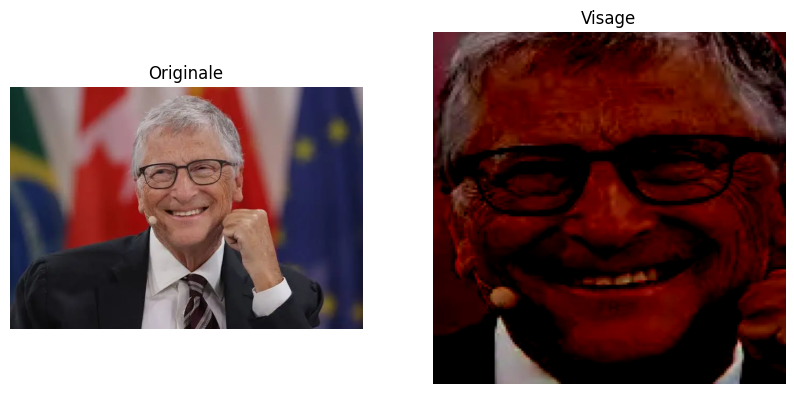

Dimension avant torch.Size([3, 160, 160])
Dimension apres torch.Size([1, 3, 160, 160])
Embedding shape: torch.Size([1, 512])


In [4]:
# Charger image de test

image = "..\\data\\images\\bill.jpg"

try:

    img = cv2.imread(str(image))
    
    if img is None:
        raise ValueError(f"Impossible de lire l'image: {image}")
    print(f"Taille image originale {img.shape}")
    
    
    

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    print(img.ndim)
    # Détecter et crop visage
    face = mtcnn(img)

    if face is not None:
        
        # Créer une figure avec 1 ligne et 2 colonnes
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))

        # Image originale
        axes[0].imshow(img)
        axes[0].set_title('Originale')
        axes[0].axis('off') 

        # Visage détecté
        axes[1].imshow(face.permute(1,2,0).detach().cpu().numpy())
        axes[1].set_title('Visage')
        axes[1].axis('off')
            
        
        plt.show()
        
        # Ajouter batch dimension
        
        print(f"Dimension avant {face.shape}")
        
        face = face.unsqueeze(0)
        
        print(f"Dimension apres {face.shape}")
        
        # Extraire embedding
        embedding = model(face)

        print("Embedding shape:", embedding.shape)
    else:
        print(f"Aucun visage détecté dans {image}")
        
except Exception as e:
    print("Une erreur s'est produite" , e)

In [5]:
# Charger une image et retourner un ndarray RGB

def load_image(path: str) -> np.ndarray:
    image_bgr = cv2.imread(str(path))

    if image_bgr is None:
        raise ValueError(f"Impossible de lire l'image: {path}")

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    print("Image chargée")

    return image_rgb

In [6]:
def show_image(image_original):
    if isinstance(image_original, torch.Tensor):
        image_original = image_original.detach().cpu().numpy()

    if image_original.ndim != 3:
        raise ValueError("Format d'image invalide: attendu [H, W, C].")

    # Créer une figure avec 1 ligne et 2 colonnes
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # Image originale
    axes[0].imshow(image_original.astype(np.uint8))
    axes[0].set_title('Originale')
    axes[0].axis('off')

    # Visage détecté
    face_detect = mtcnn(image_original)
    axes[1].set_title('Visage')
    axes[1].axis('off')

    if face_detect is not None:
        axes[1].imshow(face_detect.permute(1, 2, 0).detach().cpu().numpy())
    else:
        axes[1].text(0.5, 0.5, 'Aucun visage détecté', ha='center', va='center')

    plt.show()

In [7]:
# Transformer une image en embedding
def img_to_embedding(image_original) -> np.ndarray:
    """
    Transforme l'image originale en vecteur d'embedding.
    """
    if isinstance(image_original, torch.Tensor):
        image_original = image_original.detach().cpu().numpy()

    face_detect = mtcnn(image_original)

    if face_detect is None:
        raise ValueError("Aucun visage détecté pour calculer l'embedding.")

    face_detect = face_detect.unsqueeze(0)

    with torch.no_grad():
        embedding = model(face_detect).detach().cpu().numpy().astype("float32")

    return embedding

In [8]:
# Verifier les doublons
def is_already_encoded(new_embedding, db, threshold=0.3):
    # Calcul de la distance euclidienne entre le nouveau et toute la base
    distances = np.linalg.norm(db - new_embedding, axis=1)
    
    # Si la distance minimale est inférieure au seuil, c'est un doublon
    if np.min(distances) < threshold:
        return True
    return False

In [9]:
# Enregistrer un embedding avec verification stricte de la synchronisation

def save_embedding(
    embed: np.ndarray,
    person_name: str = None,
    image_path: str = None,
    embeddings_path: str = "../data/embeddings.npy",
    mapping_path: str = "../data/mapping.json",
    threshold: float = 0.3,
):
    if embed.shape != (1, 512):
        raise ValueError(
            f"La taille de l'embedding doit etre (1, 512), recu {embed.shape}."
        )

    embeddings_file = Path(embeddings_path)

    # Chargement de NPY
    if embeddings_file.exists():
        db = np.load(embeddings_file).astype("float32")
        if db.ndim == 1:
            db = db.reshape(1, -1)
    else:
        db = np.empty((0, 512), dtype="float32")

    mapping = load_mapping_strictly(mapping_path)

    # Controle de synchronisation AVANT toute modification
    if len(mapping) != db.shape[0]:
        raise RuntimeError(
            f"Desynchronisation detectee avant sauvegarde: mapping={len(mapping)} embeddings={db.shape[0]}"
        )

    if db.shape[0] > 0 and is_already_encoded(embed, db, threshold=threshold):
        raise ValueError("Cette photo semble deja enregistree (doublon detecte).")

    updated_db = np.concatenate((db, embed.astype("float32")), axis=0)
    new_index = int(updated_db.shape[0] - 1)

    label = person_name if person_name else f"person_{new_index}"
    mapping[str(new_index)] = {
        "name": label,
        "image_path": image_path if image_path else "",
    }

    save_mapping_and_embedding_safely(
        mapping=mapping,
        embeddings=updated_db,
        final_path_embed=embeddings_path,
        final_path_mapping=mapping_path,
    )

    print(f"Done\nTaille actuelle {updated_db.shape}")
    return new_index

In [10]:
# Charger les fichiers de mappage pour eviter toute erreur
def load_mapping_strictly(file_path :str):
    path = Path(file_path)
    
    # Cas 1 : Le fichier n'existe pas encore (Premier lancement)
    if not path.exists():
        print("Initialisation du projet : Création d'un mapping vide.")
        return {}

    # Cas 2 : Tentative de lecture
    try:
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)
            # Vérifier que c'est bien un dictionnaire
            if not isinstance(data, dict):
                raise ValueError("Le format du JSON n'est pas un dictionnaire.")
            return data

    except (json.JSONDecodeError, ValueError) as e:
        # Cas 3 : Erreur de lecture -> On cherche un fichier temporaire (.tmp) comme une sorte de sauvegarde
        temp_path = path.with_suffix(".json.tmp")
        
        if temp_path.exists():
            print(f"⚠️ Erreur de lecture sur {path}. Tentative de récupération via le fichier temporaire ...")
            try:
                with open(temp_path, "r", encoding="utf-8") as f:
                    return json.load(f)
            except:
                print("Fichier de backup est corrompu")
                pass # Si le backup foire aussi, on passe à l'exception finale
        
        # Cas 4 : Échec total -> On lève l'exception
        raise RuntimeError(
            f"IMPOSSIBLE DE CHARGER LE MAPPING : {e}\n"
            "Le fichier est corrompu et aucun backup valide n'a été trouvé. "
            "Veuillez vérifier manuellement le fichier avant de relancer."
        )

In [11]:
# Sauvegarde atomique JSON + NPY avec verification de synchronisation

def save_mapping_and_embedding_safely(
    mapping: dict,
    embeddings: np.ndarray,
    final_path_embed: str,
    final_path_mapping: str,
):
    """
    Sauvegarde atomique de mapping.json et embeddings.npy.
    Verifie la synchronisation avant ecriture definitive.
    """
    # On crée des objets pour les fichiers embeddings et mapping
    embed_path = Path(final_path_embed)
    map_path = Path(final_path_mapping)

    embed_path.parent.mkdir(parents=True, exist_ok=True)
    map_path.parent.mkdir(parents=True, exist_ok=True)

    # On refait les vérifications de bases
    if not isinstance(mapping, dict):
        raise TypeError("mapping doit etre un dictionnaire.")

    if embeddings.ndim != 2 or embeddings.shape[1] != 512:
        raise ValueError(
            f"embeddings doit avoir la forme (N, 512), recu {embeddings.shape}."
        )

    if len(mapping) != embeddings.shape[0]:
        raise ValueError(
            f"Desynchronisation detectee: mapping={len(mapping)} embeddings={embeddings.shape[0]}"
        )

    # On crée les fichiers temporaires pour l'ecriture et le backup
    map_tmp = map_path.with_suffix(".json.tmp")
    embed_tmp = embed_path.with_suffix(".npy.tmp")

    map_bak = map_path.with_suffix(".json.bak")
    embed_bak = embed_path.with_suffix(".npy.bak")

    try:
        # 1) Ecriture temporaire
        with open(map_tmp, "w", encoding="utf-8") as f:
            json.dump(mapping, f, indent=2, ensure_ascii=False)

        # Ecriture binaire explicite pour eviter que numpy ajoute automatiquement .npy
        with open(embed_tmp, "wb") as f:
            np.save(f, embeddings.astype("float32"))

        # 2) Validation des temporaires
        with open(map_tmp, "r", encoding="utf-8") as f:
            mapping_check = json.load(f)

        with open(embed_tmp, "rb") as f:
            embeddings_check = np.load(f)

        if len(mapping_check) != embeddings_check.shape[0]:
            raise RuntimeError(
                "Validation des temporaires echouee: JSON et NPY ne sont pas synchronises."
            )

        # 3) Backup puis remplacement atomique
        if map_path.exists():
            os.replace(map_path, map_bak)
        if embed_path.exists():
            os.replace(embed_path, embed_bak)

        os.replace(map_tmp, map_path)
        os.replace(embed_tmp, embed_path)

        print(f"Base synchronisee avec succes ({len(mapping)} visages).")

    except Exception as e:
        # Si n'importe quel erreur intervient on efface les fichiers temporaires
        for tmp in [map_tmp, embed_tmp]:
            if tmp.exists():
                tmp.unlink()
        raise RuntimeError(f"Echec de sauvegarde atomique: {e}") from e

In [12]:
# Sauvegarde synchroniser de NPY et JSON

def save_face_database(mapping, embeddings, folder="data"):
    """
    Sauvegarde synchronisee du JSON et du NPY.
    mapping : dictionnaire {id: nom}
    embeddings : numpy array (N, 512)
    """

    folder = Path(folder)
    folder.mkdir(exist_ok=True)

    json_path = folder / "mapping.json"
    npy_path = folder / "embeddings.npy"

    json_tmp = json_path.with_suffix(".json.tmp")
    npy_tmp = npy_path.with_suffix(".npy.tmp")

    try:
        # --- ETAPE 1 : Ecritures temporaires ---
        with open(json_tmp, "w", encoding="utf-8") as f:
            json.dump(mapping, f, indent=2, ensure_ascii=False)

        # Ecriture binaire explicite pour conserver exactement le nom .npy.tmp
        with open(npy_tmp, "wb") as f:
            np.save(f, embeddings)

        # --- ETAPE 2 : Validation croisee ---
        if len(mapping) != embeddings.shape[0]:
            raise ValueError(
                f"Desynchronisation detectee ! Mapping: {len(mapping)}, Embeddings: {embeddings.shape[0]}"
            )

        # --- ETAPE 3 : Remplacement definitif ---
        if json_path.exists():
            os.replace(json_path, json_path.with_suffix(".json.bak"))
        if npy_path.exists():
            os.replace(npy_path, npy_path.with_suffix(".npy.bak"))

        os.replace(json_tmp, json_path)
        os.replace(npy_tmp, npy_path)

        print(f"Base synchronisee avec succes ({len(mapping)} visages).")

    except Exception as e:
        print(f"ECHEC DE SAUVEGARDE : {e}")
        for tmp in [json_tmp, npy_tmp]:
            if tmp.exists():
                tmp.unlink()
        raise

In [13]:
# Pipeline complet

def pipeline_save_image(
    image_path: str,
    person_name: str = None,
    embeddings_path: str = "../data/embeddings.npy",
    mapping_path: str = "../data/mapping.json",
    threshold: float = 0.3,
    preview: bool = True,
):
    """
    Enregistre une image dans la base de vecteurs via une sauvegarde atomique.

    Etapes:
    1) charge l'image
    2) affiche l'image + visage detecte (optionnel)
    3) extrait l'embedding
    4) verifie les doublons
    5) verifie la synchronisation mapping/embeddings
    6) sauvegarde atomique JSON + NPY
    """

    image_array = load_image(image_path)

    if preview:
        show_image(image_array)

    new_embedding = img_to_embedding(image_array).astype("float32")

    if new_embedding.shape != (1, 512):
        raise ValueError(
            f"Embedding invalide: attendu (1, 512), obtenu {new_embedding.shape}"
        )

    # Chemin unique de sauvegarde: save_embedding gere
    # - verification de synchro
    # - detection de doublon
    # - sauvegarde atomique mapping + embeddings
    new_index = save_embedding(
        embed=new_embedding,
        person_name=person_name,
        image_path=image_path,
        embeddings_path=embeddings_path,
        mapping_path=mapping_path,
        threshold=threshold,
    )

    updated_db = np.load(embeddings_path).astype("float32")
    mapping = load_mapping_strictly(mapping_path)

    if len(mapping) != updated_db.shape[0]:
        raise RuntimeError(
            f"Desynchronisation apres sauvegarde: mapping={len(mapping)} embeddings={updated_db.shape[0]}"
        )

    label = mapping[str(new_index)]["name"]

    print(f"Image enregistree avec succes. Index: {new_index}")
    print(f"Nouvelle taille de la base: {updated_db.shape}")

    return {
        "index": new_index,
        "name": label,
        "image_path": str(image_path),
        "embedding_shape": tuple(new_embedding.shape),
        "db_shape": tuple(updated_db.shape),
    }

Image chargée


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.98046875..0.99609375].


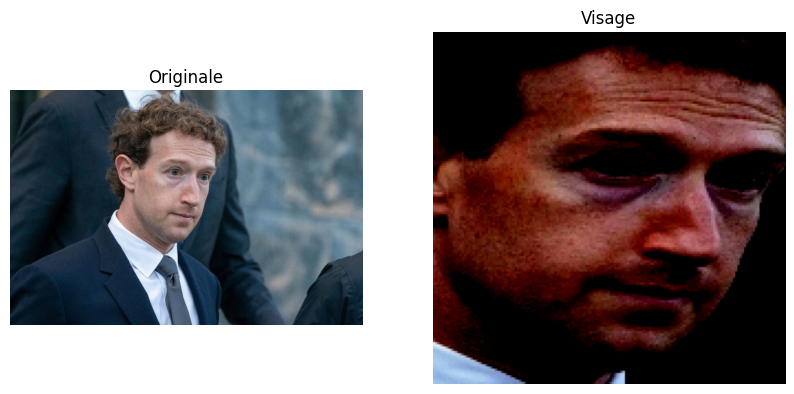

In [14]:
# Charger image de Elon

elon_path = "..\\data\\images\\markzuck.jpg"

elon_array = load_image(elon_path)

show_image(elon_array)

elon_embedding = img_to_embedding(elon_array)

In [15]:
# Fonction pour charger les images d'un dossier
def lister_images_du_dossier(chemin_dossier):
    """
    Récupère uniquement les images présentes directement dans le dossier spécifié.
    """
    dossier = Path(chemin_dossier)
    
    # Liste des extensions que l'on accepte
    extensions = {".jpg", ".jpeg", ".png", ".webp"}
    
    # On filtre : c'est un fichier ET son extension est dans notre liste
    images = [
        f for f in dossier.iterdir() 
        if f.is_file() and f.suffix.lower() in extensions
    ]
    
    print(f"✅ {len(images)} images trouvées dans '{dossier.name}'")
    return images


Image chargée


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99609375..0.98828125].


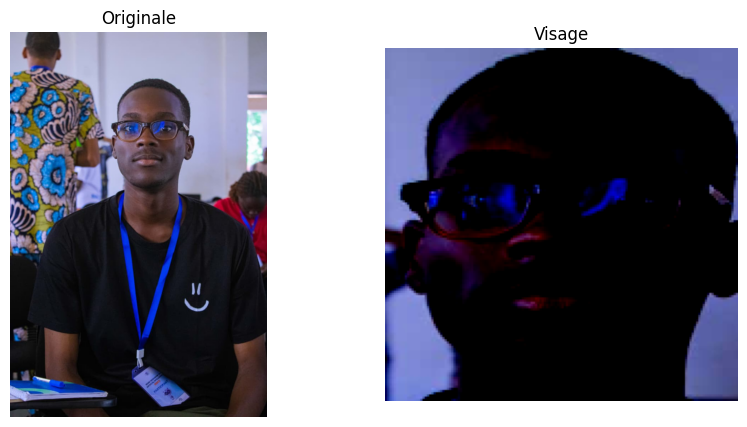

Base synchronisee avec succes (6 visages).
Done
Taille actuelle (6, 512)
Image enregistree avec succes. Index: 5
Nouvelle taille de la base: (6, 512)


In [39]:
img = pipeline_save_image("..\\data\\images\\freud.jpg" , person_name="Freud")

    

# Selection des vecteurs suivant la similarité et reaffichage 


In [17]:

def calc_distance_with_faiss(database:np.ndarray , vector:np.ndarray , dimension = 512):
    


    # Créer + peupler l'index
    index = faiss.IndexFlatL2(dimension)
    index.add(database)

    # Recherche des 5 plus proches voisins
    
    D, I = index.search(vector, k=5)
    # D: distances (n_queries, k)  I: indices (n_queries, k)
    
    return {"distances" : D , "indices" : I}

In [18]:
database = np.load("..\\data\\embeddings.npy")
vector = img_to_embedding( load_image("..\\data\\images\\Laurent.jpg") )


print(calc_distance_with_faiss(database=database , vector=vector))


Image chargée
{'distances': array([[0.       , 1.6384585, 1.8084459, 1.9676397, 2.1823988]],
      dtype=float32), 'indices': array([[4, 0, 1, 2, 3]])}


## Formule du softmax avec température

$$P_i = \frac{e^{\frac{-d_i - \max(-d)}{T}}}{\sum e^{\frac{-d_j - \max(-d)}{T}}}$$

In [32]:
# Probabilites softmax simples

def distances_to_probs(distances, T=0.1):
    """Convertit une liste de distances en probabilites.

    Plus la distance est petite, plus la probabilite est grande.
    T controle la douceur de la distribution.
    """
    distances = np.asarray(distances, dtype="float32").reshape(-1)

    if distances.size == 0:
        return np.array([], dtype="float32")

    if T <= 0:
        raise ValueError("T doit etre strictement positif.")

    # Softmax inverse: on favorise les petites distances
    
    # En reconnaissance faciale, une petite distance = une grande ressemblance. En mettant un signe moins, on transforme les distances (ex: 0.1, 0.5, 0.9) en scores (ex: -0.1, -0.5, -0.9). Ainsi, le plus grand nombre (le moins négatif) devient celui qui est le plus proche.

    scores = -distances / T
    
    # Mathématiquement, $e^{x}$ grandit extrêmement vite un x trop grand  peur provoquer Erreur d'Infini ou Overflow .L'astuce : En soustrayant le maximum de tous les scores, le plus grand score devient 0 ($e^0 = 1$) et tous les autres deviennent négatifs.Résultat : On travaille uniquement avec des nombres entre 0 et 1. Ça ne change pas les proportions finales, mais ça empêche le programme de crasher.
    
    scores = scores - np.max(scores)
    
    # np.exp : On passe à l'exponentielle pour s'assurer que tous nos résultats sont positifs (on ne peut pas avoir une probabilité de -5%).
    
    exp_scores = np.exp(scores)
    
    #total : On calcule la somme de toutes ces valeurs pour pouvoir diviser et obtenir un total de 100% (1.0).
    
    total = np.sum(exp_scores)

    # Si, pour une raison bizarre (distances infinies), le total est nul, on ne peut pas diviser.La solution : On renvoie une répartition équitable. Si tu as 3 candidats, on donne 33% à chacun ($1/3$). C'est une manière de dire : "Je ne sais pas, ils se ressemblent tous ou sont tous trop loin". C'est peu probable cela dit
    if total == 0:
        return np.full(distances.shape[0], 1.0 / distances.shape[0], dtype="float32")

    # On divise chaque score par le total.
    return (exp_scores / total).astype("float32")


# Exemple : Tu as trouvé 3 personnes avec ces distances euclidiennes
dist = [0.2, 0.45, 1.60]  # Le premier est le plus proche
noms = ["Freud", "Anne", "Inconnu"]

probs = distances_to_probs(dist, T=0.1)

for i in range(len(noms)):
    print(f"{noms[i]} : {probs[i]*100:.2f}% de ressemblance")

Freud : 92.41% de ressemblance
Anne : 7.59% de ressemblance
Inconnu : 0.00% de ressemblance


In [33]:
probs = distances_to_probs(calc_distance_with_faiss(database=database , vector=vector)["distances"] , T=0.3)

probs

array([9.9130869e-01, 4.2101471e-03, 2.3889958e-03, 1.4052667e-03,
       6.8685191e-04], dtype=float32)

In [34]:
# Fonction pour recuperer les correspondances les plus similaires
# et retourner un dictionnaire ordonne par similarite.
def find_path(mapping: str, results: dict, top_k: int | None = None, temperature: float = 0.3):
    """
    Retourne un dictionnaire ordonne des meilleurs matches FAISS.

    Format de sortie:
    {0: {"name": ..., "image_path": ..., "probability": ..., "distance": ...}, ...}
    """
    if not isinstance(results, dict):
        raise TypeError("results doit etre un dictionnaire retourne par FAISS.")

    if "indices" not in results or "distances" not in results:
        raise ValueError("results doit contenir les cles 'indices' et 'distances'.")

    indices = np.asarray(results["indices"])
    distances = np.asarray(results["distances"], dtype="float32")

    if indices.size == 0 or distances.size == 0:
        return {}

    if indices.ndim == 2:
        indices = indices[0]
    if distances.ndim == 2:
        distances = distances[0]

    if indices.shape[0] != distances.shape[0]:
        raise ValueError(
            f"Incoherence entre indices ({indices.shape[0]}) et distances ({distances.shape[0]})."
        )

    mapping_data = load_mapping_strictly(mapping)
    if not isinstance(mapping_data, dict):
        raise TypeError("Le fichier de mapping doit contenir un dictionnaire JSON.")

    valid_items = []
    for idx, distance in zip(indices.tolist(), distances.tolist()):
        key = str(int(idx))
        if key not in mapping_data:
            continue

        entry = mapping_data[key]
        if not isinstance(entry, dict):
            continue

        valid_items.append(
            {
                "index": int(idx),
                "name": entry.get("name", "unknown"),
                "image_path": entry.get("image_path", ""),
                "distance": float(distance),
            }
        )

    if not valid_items:
        return {}

    if top_k is not None:
        top_k = max(1, min(int(top_k), len(valid_items)))
        valid_items = valid_items[:top_k]

    probabilities = distances_to_probs(
        [item["distance"] for item in valid_items],
        T=temperature,
    )

    ordered_matches = {}
    for rank, (item, probability) in enumerate(zip(valid_items, probabilities)):
        ordered_matches[rank] = {
            "name": item["name"],
            "image_path": item["image_path"],
            "probability": float(probability),
            "distance": item["distance"],
        }

    return ordered_matches


# Exemple d'utilisation
matches = find_path(
    "..\\data\\mapping.json",
    results=calc_distance_with_faiss(database=database, vector=vector),
    top_k=5,
    temperature=0.3,
)

matches

{0: {'name': 'Laurent',
  'image_path': '..\\data\\images\\Laurent.jpg',
  'probability': 0.9913086891174316,
  'distance': 0.0},
 1: {'name': 'Mark Zuckerberg',
  'image_path': '..\\data\\images\\markzuck.jpg',
  'probability': 0.004210147075355053,
  'distance': 1.638458490371704},
 2: {'name': 'Andréa',
  'image_path': '..\\data\\images\\Androu.jpg',
  'probability': 0.0023889958392828703,
  'distance': 1.808445930480957},
 3: {'name': 'Bill Gates',
  'image_path': '..\\data\\images\\bill.jpg',
  'probability': 0.0014052666956558824,
  'distance': 1.967639684677124},
 4: {'name': 'Elon Musk',
  'image_path': '..\\data\\images\\Elonmusk.jpg',
  'probability': 0.0006868519121780992,
  'distance': 2.182398796081543}}

Image chargée
Image chargée


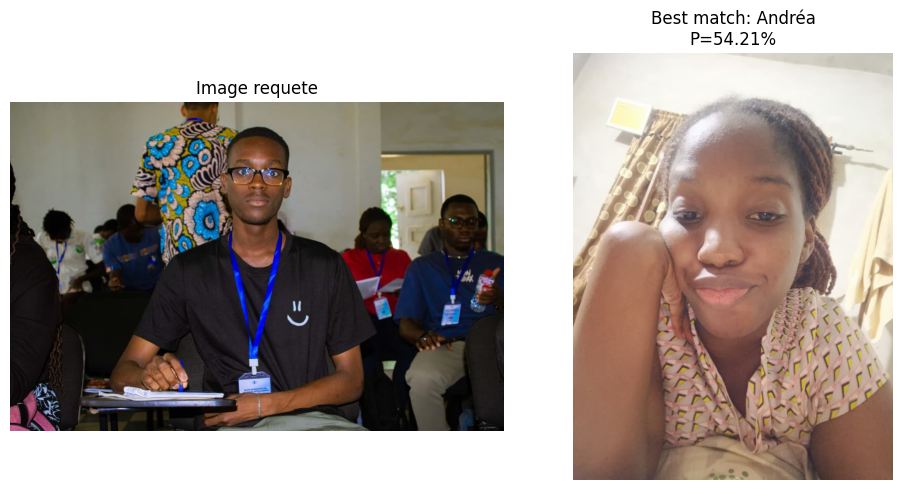

{'query_image': '..\\data\\test\\test.png', 'best_match': {'name': 'Andréa', 'image_path': '..\\data\\images\\Androu.jpg', 'probability': 0.542136549949646, 'distance': 1.6211177110671997}, 'top_k': {0: {'name': 'Andréa', 'image_path': '..\\data\\images\\Androu.jpg', 'probability': 0.542136549949646, 'distance': 1.6211177110671997}, 1: {'name': 'Freud', 'image_path': '..\\data\\images\\freud.jpg', 'probability': 0.20049309730529785, 'distance': 1.919539213180542}, 2: {'name': 'Mark Zuckerberg', 'image_path': '..\\data\\images\\markzuck.jpg', 'probability': 0.11384414881467819, 'distance': 2.0893239974975586}, 3: {'name': 'Elon Musk', 'image_path': '..\\data\\images\\Elonmusk.jpg', 'probability': 0.09152442961931229, 'distance': 2.1547913551330566}, 4: {'name': 'Laurent', 'image_path': '..\\data\\images\\Laurent.jpg', 'probability': 0.052001744508743286, 'distance': 2.324389934539795}}}


In [42]:
def recognize_face(
    image_path: str,
    embeddings_path: str = "..\\data\\embeddings.npy",
    mapping_path: str = "..\\data\\mapping.json",
    k: int = 5,
    temperature: float = 0.3,
    show_best_match: bool = True,
):
    """
    Pipeline complet de reconnaissance:
    1) charge l'image requete
    2) calcule son embedding
    3) cherche les k plus proches dans FAISS
    4) retourne les resultats ordonnes avec probabilites
    5) affiche le meilleur match si show_best_match=True
    """
    if k <= 0:
        raise ValueError("k doit etre >= 1")

    # Verifications minimales des fichiers de base
    db_path = Path(embeddings_path)
    if not db_path.exists():
        raise FileNotFoundError(f"Base introuvable: {embeddings_path}")

    mapping_data = load_mapping_strictly(mapping_path)
    if not isinstance(mapping_data, dict):
        raise TypeError("Le mapping doit etre un dictionnaire.")

    database = np.load(embeddings_path).astype("float32")
    if database.ndim != 2 or database.shape[1] != 512:
        raise ValueError(f"Base invalide, attendu (N, 512), recu {database.shape}")

    if database.shape[0] == 0:
        raise ValueError("La base embeddings est vide.")

    if len(mapping_data) != database.shape[0]:
        raise RuntimeError(
            f"Desynchronisation detectee: mapping={len(mapping_data)} embeddings={database.shape[0]}"
        )

    # Image requete + embedding
    query_img = load_image(image_path)
    query_vec = img_to_embedding(query_img).astype("float32")

    # Recherche FAISS + conversion en matches ordonnes
    k_search = min(int(k), database.shape[0])
    faiss_results = calc_distance_with_faiss(database=database, vector=query_vec, dimension=512)

    ordered_matches = find_path(
        mapping=mapping_path,
        results=faiss_results,
        top_k=k_search,
        temperature=temperature,
    )

    if not ordered_matches:
        return {"query_image": image_path, "best_match": None, "top_k": {}}

    best_match = ordered_matches[0]

    # Affichage du meilleur match
    if show_best_match:
        best_img_path = best_match.get("image_path", "")

        fig, axes = plt.subplots(1, 2, figsize=(10, 5))

        axes[0].imshow(query_img)
        axes[0].set_title("Image requete")
        axes[0].axis("off")

        if best_img_path and Path(best_img_path).exists():
            best_img = load_image(best_img_path)
            axes[1].imshow(best_img)
            axes[1].set_title(
                f"Best match: {best_match['name']}\nP={best_match['probability']:.2%}"
            )
            axes[1].axis("off")
        else:
            axes[1].text(
                0.5,
                0.5,
                f"Best match: {best_match['name']}\nImage introuvable",
                ha="center",
                va="center",
            )
            axes[1].axis("off")

        plt.tight_layout()
        plt.show()

    return {
        "query_image": str(image_path),
        "best_match": best_match,
        "top_k": ordered_matches,
    }


# Exemple d'appel
result = recognize_face(
    image_path="..\\data\\test\\test.png",
    embeddings_path="..\\data\\embeddings.npy",
    mapping_path="..\\data\\mapping.json",
    k=5,
    temperature=0.3,
    show_best_match=True,
)

print(result)

data.shape

In [ ]:


# 1. Préparation des données (vecteurs à indexer)
d = 64                           # dimension
nb = 100000                      # nombre de vecteurs
nq = 10                          # nombre de requêtes
np.random.seed(1234)             
xb = np.random.random((nb, d)).astype('float32')
xq = np.random.random((nq, d)).astype('float32')

# 2. Création de l'index
index = faiss.IndexFlatL2(d)   # utilise L2 (euclidien)
print(index.is_trained)
index.add(xb)                  # ajout des vecteurs
print(index.ntotal)

# 3. Recherche
k = 4                          # nombre de voisins à retourner
D, I = index.search(xq, k)     # D=distances, I=index
print(D)                   # indices des 5 premières requêtes


True
100000
[[5.6056523 5.8574157 5.864208  5.919097 ]
 [4.840672  5.120595  5.237412  5.274076 ]
 [5.315844  5.8178043 5.8179564 5.9018445]
 [5.2199526 5.233007  5.3548164 5.5242834]
 [4.865439  5.146442  5.22618   5.3562737]
 [5.024254  5.2272964 5.3044915 5.3150125]
 [4.998722  5.170163  5.1894617 5.2167225]
 [5.341447  5.4327292 5.60601   5.6427364]
 [5.2383704 5.385066  5.600378  5.6291046]
 [5.7070546 5.7532673 5.8351126 5.9764414]]


In [ ]:
# Convertir le tenseur en array numpy
# embeddings_array = embedding.detach().cpu().numpy()
np.save('../data/embeddings.npy', data)

In [ ]:
# Il faut charger les anciens d'abord ; faire un concat ; et ensuite enregistrer de nouveau
a = np.load('../data/embeddings.npy').shape
a

(1, 512)

In [ ]:
# Ouvrir le fichier YAML en mode lecture
with open("../configs/config.yaml", "r") as file:
    # Charger le contenu du fichier en tant que dictionnaire Python
    config = yaml.safe_load(file)

# Afficher le contenu du fichier chargé
print(config)

{'face_recognition': {'model_name': 'face_recognition_facenet', 'params': {'distance_threshold': 0.75, 'model_path': '../../../data/models/face_recognition_facenet/squeezenet_VGGFace2/model-20180204-160909.ckpt-266000', 'use_cuda': True}}}
